In [41]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
from alive_progress import alive_bar
import ast

In [42]:
# raw = pd.read_csv('../data/edges_saigon.csv')
# labels = pd.read_csv('../output/scored_edges_saigon.csv')
# labels['geometry'] = raw['geometry']
# labels.to_csv('../output/scored_edges_saigon.csv', index=False)

In [43]:
edges_df = pd.read_csv('../data/edges_seattle.csv')
geo_df = pd.read_csv('../output/accessibility_scored_edges_slope.csv')

# type_severity_df = pd.read_csv(r'C:\Users\vzhang\OneDrive - Eastside Preparatory School\Documents\Walkability\access_type_severity.csv')
labels_df = pd.read_csv('../data/proj_sidewalk_labels.csv')

type_severity = {'Obstacle': 0.61,
                      'SurfaceProblem': 0.5,
                      'CurbRamp': 0.33,
                      'NoCurbRamp': 0.5,
                      'NoSidewalk': 0.5,
                      'Occlusion': 0.5,
                      'Other': 0.5}

print("Finished loading dataframes.")


Finished loading dataframes.


In [44]:
# 6. Function to summarize notes
def make_note(labels_sev):
    final = {}
    for pair in labels_sev:
        for label, severity in pair.items():
            if label in final:
                final[label].append(severity) if severity != 'nan' else final[label].append(1)
            else:
                final[label] = [severity]
    messages = []
    for label in final:
        avg_sev = sum(final[label]) / len(final[label])
        messages.append({label: [len(final[label]), avg_sev]})
    return messages

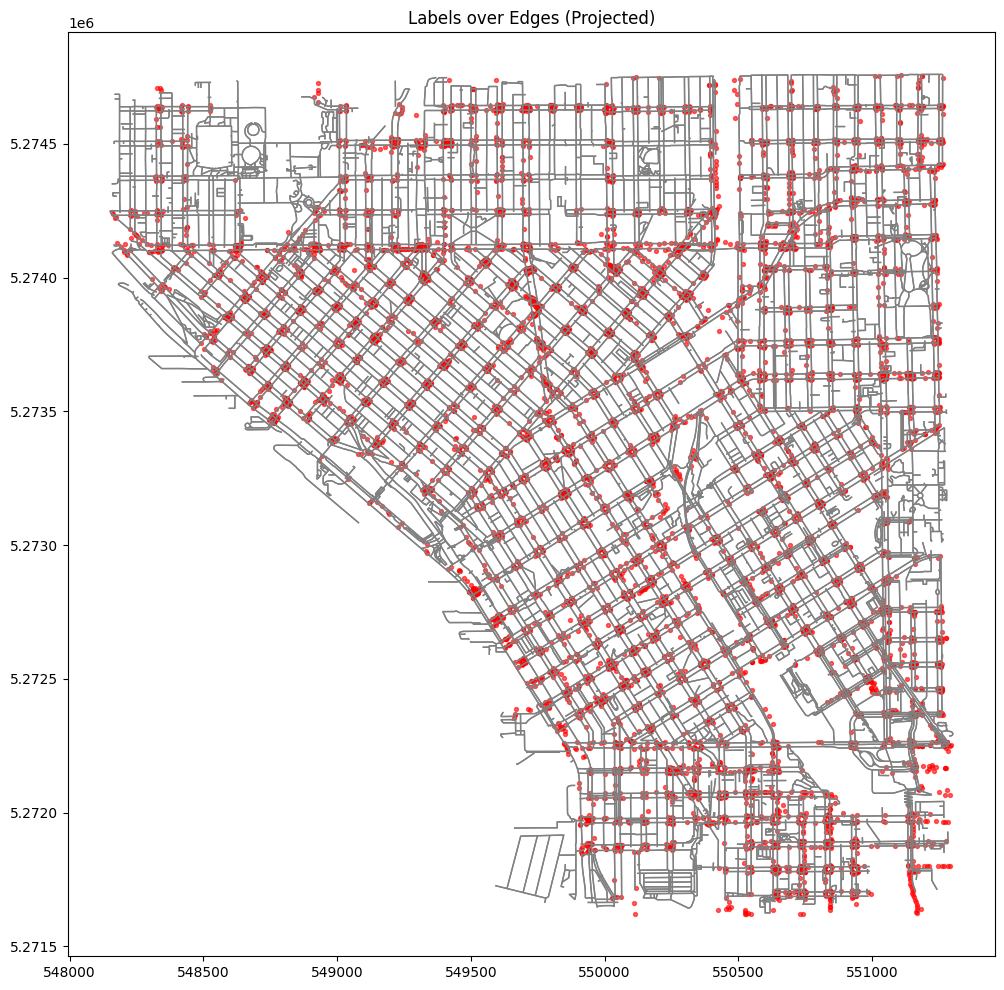

In [45]:
# 2. Convert to GeoDataFrames
labels_gdf = gpd.GeoDataFrame(
    labels_df,
    geometry=gpd.points_from_xy(labels_df['Attribute Longitude'], labels_df['Attribute Latitude']),
    crs="EPSG:4326"
)

edges_gdf = gpd.GeoDataFrame(
    edges_df,
    geometry=edges_df['geometry'].apply(wkt.loads),
    crs="EPSG:4326"
)

# 3. Project to UTM zone for Seattle (meters)
projected_crs = "EPSG:32610"
labels_gdf = labels_gdf.to_crs(projected_crs)
edges_gdf = edges_gdf.to_crs(projected_crs)

import matplotlib.pyplot as plt

base = edges_gdf.plot(figsize=(12, 12), linewidth=1, color="gray")
labels_gdf.plot(ax=base, markersize=8, color="red", alpha=0.6)
plt.title("Labels over Edges (Projected)")
plt.show()

In [ ]:
def map_labels(BUFFER_METERS):
    print(f"Mapping labels with buffer {BUFFER_METERS} meters...")
    label_buffers = labels_gdf.copy()
    label_buffers["geometry"] = label_buffers.buffer(BUFFER_METERS)
    #label_buffers.crs = projected_crs

    joined = gpd.sjoin(
        edges_gdf,           # segments = left
        label_buffers,       # buffered labels = right
        how="left",
        predicate="intersects"
    )

    # Group all labels intersecting each edge
    labels_by_edge = {
        idx: group.to_dict(orient="records")
        for idx, group in joined.groupby(joined.index)
    }


    # 8. Only recalculate where AccessScore isn't already set
    access_scores = []
    notes = []
    count=0
    with alive_bar(len(edges_gdf), force_tty=True) as bar:
        for idx, edge in edges_gdf.iterrows():
            edge_labels = labels_by_edge.get(idx, [])
            weighted = []
            label_sevs = []
            for label in edge_labels:
                ltype = label.get("Label Type")
                sev = label.get("Severity", 1) if label.get("Severity") != 'nan' else 1
                if ltype in type_severity:
                    weight = type_severity[ltype]
                    weighted.append((sev / 5) * (weight))
                    label_sevs.append({ltype: sev})

            if weighted:
                # length_m = edge.geometry.length
                # density = len(weighted) / min(length_m, 150)
                score = 1 - min(1, 0.8 * sum(weighted))
                note = make_note(label_sevs)
                count += 1
            else:
                score = 1.0
                note = {}

            access_scores.append(score)
            notes.append(note)
            bar()
    count=0
    count2=0
    # 9. Save results
    edges_gdf["AccessScore"] = access_scores
    for a in access_scores:
        if a==0:
            count += 1
        count2 +=1
    print(count / count2 * 100, "% of edges have no sidewalk.")
    # edges_gdf.drop(columns=['geometry', 'notes'], inplace=True, errors='ignore')
    # edges_gdf['geometry'] = geo_df['geometry']
    # edges_gdf["sidewalk_notes"] = notes
    # edges_gdf.to_csv("../output/scored_edges_no_distance.csv", index=False)
    print(count, "edges scored.")

In [ ]:
def map_slope(BUFFER_METERS):
    new_df = pd.read_csv(rf'C:\Users\vzhang\Documents\GitHub\Robotics\STARSWalkability\accesscore\output\scored_edges_buffer_{BUFFER_METERS}.csv')
    accesscores_slope = []  # Final adjusted access scores (accounting for slope & elevation)

    with alive_bar(len(new_df), force_tty=True) as bar:
        try:
            for idx, row in new_df.iterrows():
                if row['slope_included_in_as'] == False:
                    # Slope penalty term:
                    max_slope = ast.literal_eval(row['slope_metrics'])['abs_max_slope']
                    p1 = (max_slope - 0.083) * (max_slope + 1) if max_slope > 0.083 else 0
                    p2 = ast.literal_eval(row['slope_metrics'])['abs_elevation_diff'] / 100
                    adjusted_score = row['AccessScore'] - p1 - p2
                    accesscores_slope.append(max(adjusted_score, 0))
                else:
                    accesscores_slope.append(row['AccessScore'])
                bar()
        except Exception as e:
            print("Partial scores:", accesscores_slope)
            raise e
    new_df['AccessScore_slope'] = accesscores_slope
    #new_df.to_csv(rf'C:\Users\vzhang\Documents\GitHub\Robotics\STARSWalkability\accesscore\output\scored_edges_buffer_{BUFFER_METERS}.csv', index=False)
    print("Slope adjustment complete for buffer size:", BUFFER_METERS)

In [ ]:
print()

In [48]:
map_labels(5)  # Adjust buffer size as needed

Mapping labels with buffer 5 meters...
|████████████████████████████████████████| 25886/25886 [100%] in 1.8s (14768.68/


C:\Users\vzhang\AppData\Local\Temp\ipykernel_11232\1700572242.py:66: UserWarning: Geometry column does not contain geometry.
  edges_gdf['geometry'] = geo_df['geometry']


15740 edges scored.
